# 00 · Setup & the data

**Project:** explore Spotify audio-feature data to find a story worth telling.

We use two public Kaggle datasets (both download without auth via `scripts/download_data.sh`):

| | dataset | rows | has genre? | has year? |
|---|---|---|---|---|
| **A** | `ultimate-spotify-tracks-db` | ~232k | ✅ 26 genres | ❌ |
| **B** | `spotify-dataset-19212020-600k` | ~587k | ⚠️ (via artists) | ✅ 1922–2021 |

Both expose the same **9 continuous audio features**, which is what makes them comparable. This notebook loads, cleans, profiles, and — most importantly — *shows* you the data.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore

## Dataset A — genre + audio features
One row per *(track, genre)* pair, so a track can appear several times.

In [2]:
a = load_genre()
print(f'{len(a):,} rows · {a.track_id.nunique():,} unique tracks · {a.genre.nunique()} genres')
a.head(3)

232,724 rows · 176,773 unique tracks · 26 genres


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.0,C#,0.346,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.0,F#,0.151,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.0,C,0.103,-13.879,Minor,0.0362,99.488,5/4,0.368


### How fuzzy are genre labels?
If the *same track* is filed under several genres, the boundaries are already blurry.

19.9% of tracks carry 2+ genre labels (max 8 on one track)


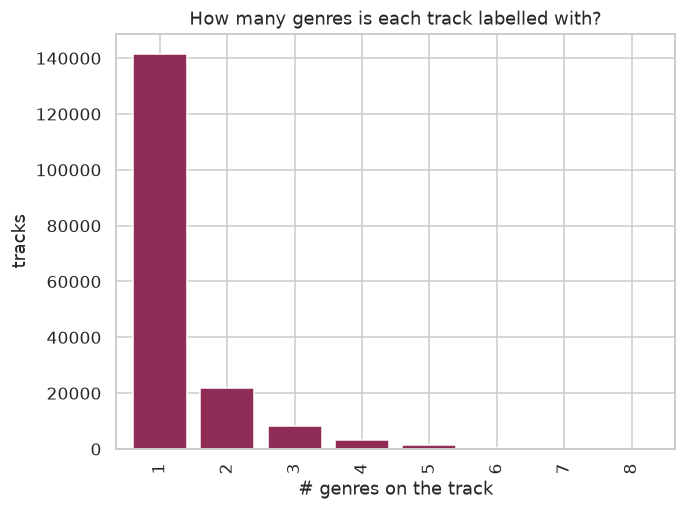

In [3]:
per_track = a.groupby('track_id')['genre'].nunique()
multi = (per_track > 1).mean()
print(f'{multi:.1%} of tracks carry 2+ genre labels (max {per_track.max()} on one track)')
vc = per_track.value_counts().sort_index()
ax = vc.plot.bar(color='#8f2d56', width=.8)
ax.set_title('How many genres is each track labelled with?')
ax.set_xlabel('# genres on the track'); ax.set_ylabel('tracks'); plt.tight_layout(); plt.show()

**Takeaway:** ~1 in 5 tracks is officially multi-genre — a first hint that genres overlap.

## Dataset B — the 100-year timeline
`load_timeline()` parses `release_date` into `year`/`decade` and drops bad years.

In [4]:
b = load_timeline()
print(f'{len(b):,} rows · years {b.year.min()}–{b.year.max()}')
b[['name','artists','year','energy','valence','acousticness']].head(3)

586,600 rows · years 1922–2021


,name,artists,year,energy,valence,acousticness
0,Carve,['Uli'],1922,0.445,0.127,0.674
1,Capítulo 2.16 - Banquero Anarquista,['Fernando Pessoa'],1922,0.263,0.655,0.797
2,Vivo para Quererte - Remasterizado,['Ignacio Corsini'],1922,0.177,0.457,0.994


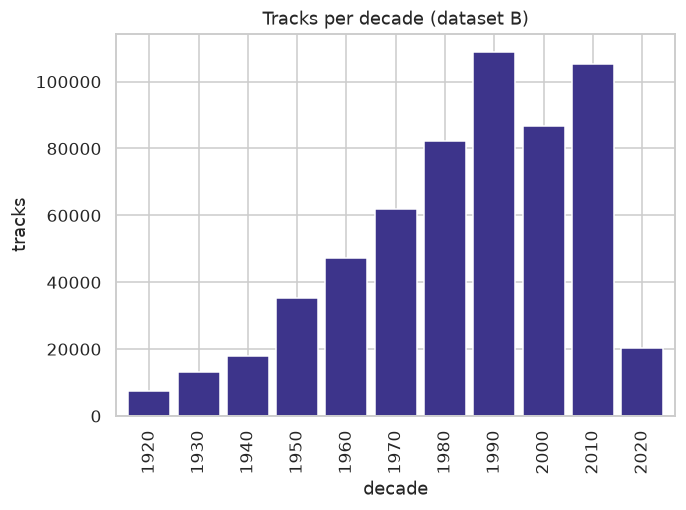

In [5]:
dec = b.decade.value_counts().sort_index()
ax = dec.plot.bar(color='#3d348b', width=.85)
ax.set_title('Tracks per decade (dataset B)'); ax.set_xlabel('decade'); ax.set_ylabel('tracks')
plt.tight_layout(); plt.show()

**Takeaway:** solid coverage from the 1920s to the 2020s — enough to study change over time.

## The audio features, explained

Spotify's audio analysis reduces every track to a handful of numbers. Most are algorithmic *estimates* (a model's best guess from the waveform), not ground truth — worth remembering when we interpret them. These **nine continuous features** are shared by both datasets and drive the whole analysis:

| feature | range | what it means |
|---|---|---|
| **acousticness** | 0–1 | confidence the track is *acoustic* (guitars/piano vs synths/electric). |
| **danceability** | 0–1 | how danceable — tempo regularity, beat strength, rhythm stability. |
| **energy** | 0–1 | perceived intensity & activity: fast, loud, noisy → high. |
| **instrumentalness** | 0–1 | likelihood of *no vocals* (>0.5 ≈ probably instrumental). |
| **liveness** | 0–1 | probability it was recorded *live* (audience present). |
| **loudness** | ~ −60→0 dB | overall average loudness (louder = closer to 0). |
| **speechiness** | 0–1 | presence of *spoken words* (>0.66 ≈ talk/podcast; <0.33 ≈ music). |
| **tempo** | BPM | estimated speed in beats per minute. |
| **valence** | 0–1 | musical *positivity* — high = happy/cheerful, low = sad/angry. |

The datasets also carry descriptive fields we use as context but not as features: `popularity` (0–100), `key` & `mode` (major/minor), `duration_ms`, and `time_signature`.

Their actual ranges and central tendencies (dataset A):

In [6]:
a[AUDIO].describe().T[['mean','std','min','50%','max']].round(2)

,mean,std,min,50%,max
acousticness,0.37,0.35,0.00,0.23,1.00
danceability,0.55,0.19,0.06,0.57,0.99
energy,0.57,0.26,0.00,0.60,1.00
instrumentalness,0.15,0.30,0.00,0.00,1.00
liveness,0.22,0.20,0.01,0.13,1.00
loudness,-9.57,6.00,-52.46,-7.76,3.74
speechiness,0.12,0.19,0.02,0.05,0.97
tempo,117.67,30.90,30.38,115.78,242.90
valence,0.45,0.26,0.00,0.44,1.00


### What each feature's distribution looks like
Note the skew: `speechiness`, `instrumentalness`, `liveness`, `acousticness` pile up near zero with a long tail, while `danceability`, `energy`, and `valence` spread across the 0–1 range.

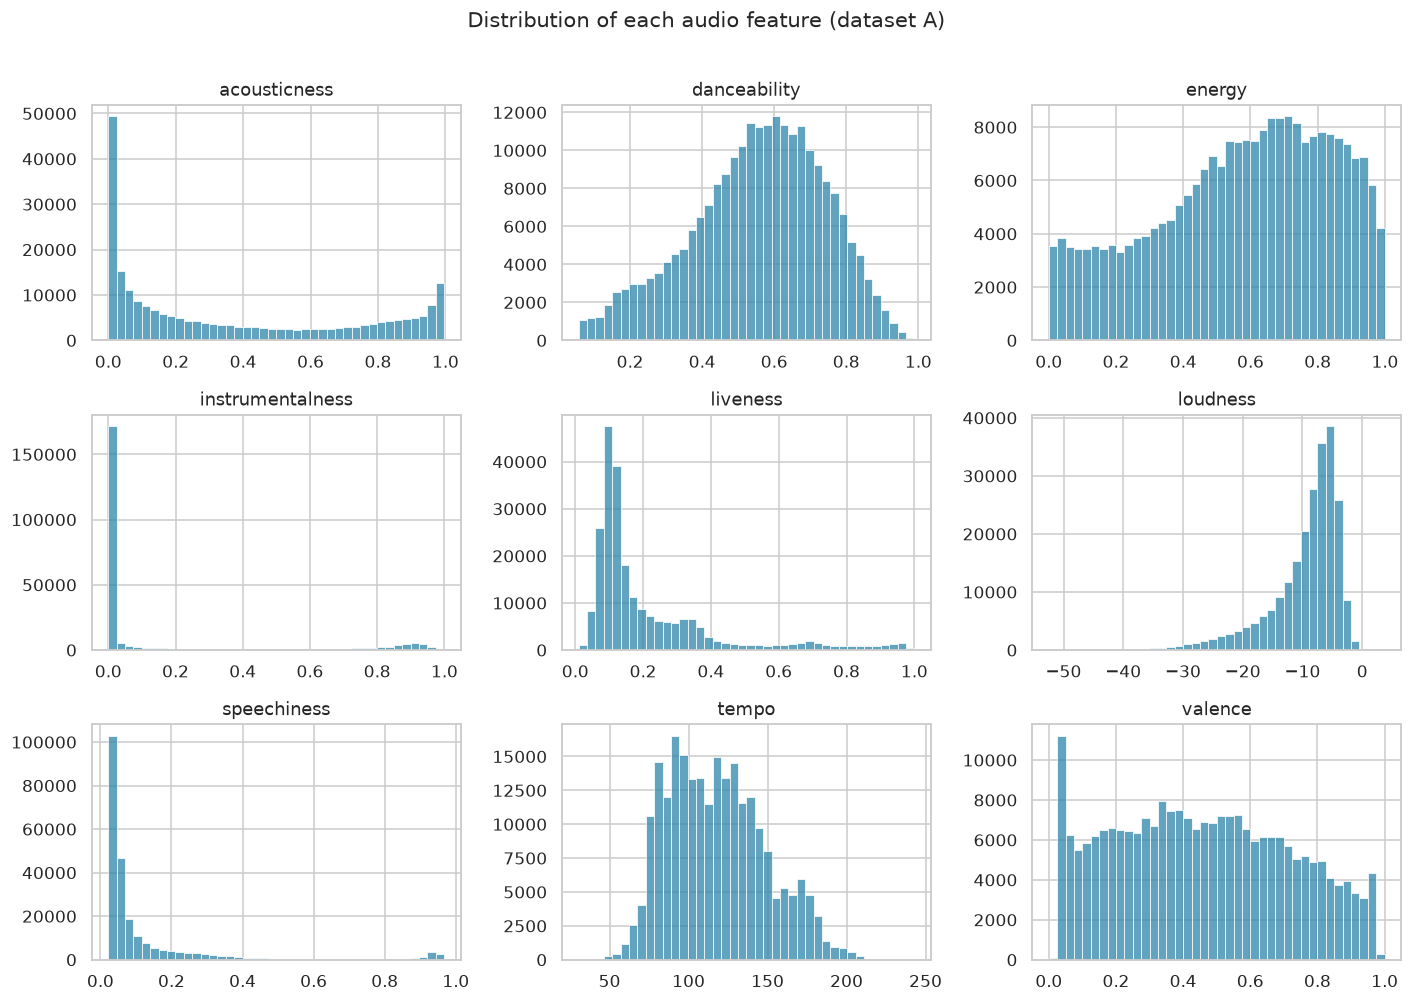

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, f in zip(axes.ravel(), AUDIO):
    sns.histplot(a[f], bins=40, ax=ax, color='#2e86ab')
    ax.set_title(f); ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Distribution of each audio feature (dataset A)', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

### How the features relate to each other
Some features move together. `energy`↔`loudness` are strongly positive; both are strongly *negative* with `acousticness` — the seed of the 'electrification' story in notebook 02.

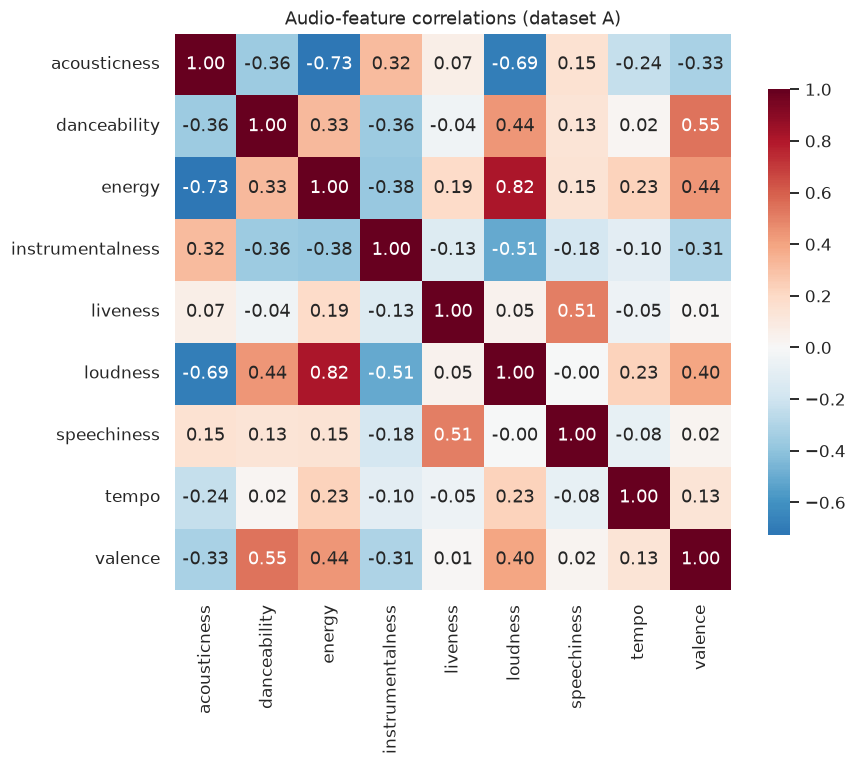

In [8]:
corr = a[AUDIO].corr()
plt.figure(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': .8})
plt.title('Audio-feature correlations (dataset A)'); plt.tight_layout(); plt.show()

### A first glimpse of genre fingerprints
Average each feature within each genre, standardized across genres (red = high for that genre, blue = low). Even at a glance, genres have distinct 'signatures' — but also share a lot. Notebook 01 digs into how *real* those differences are.

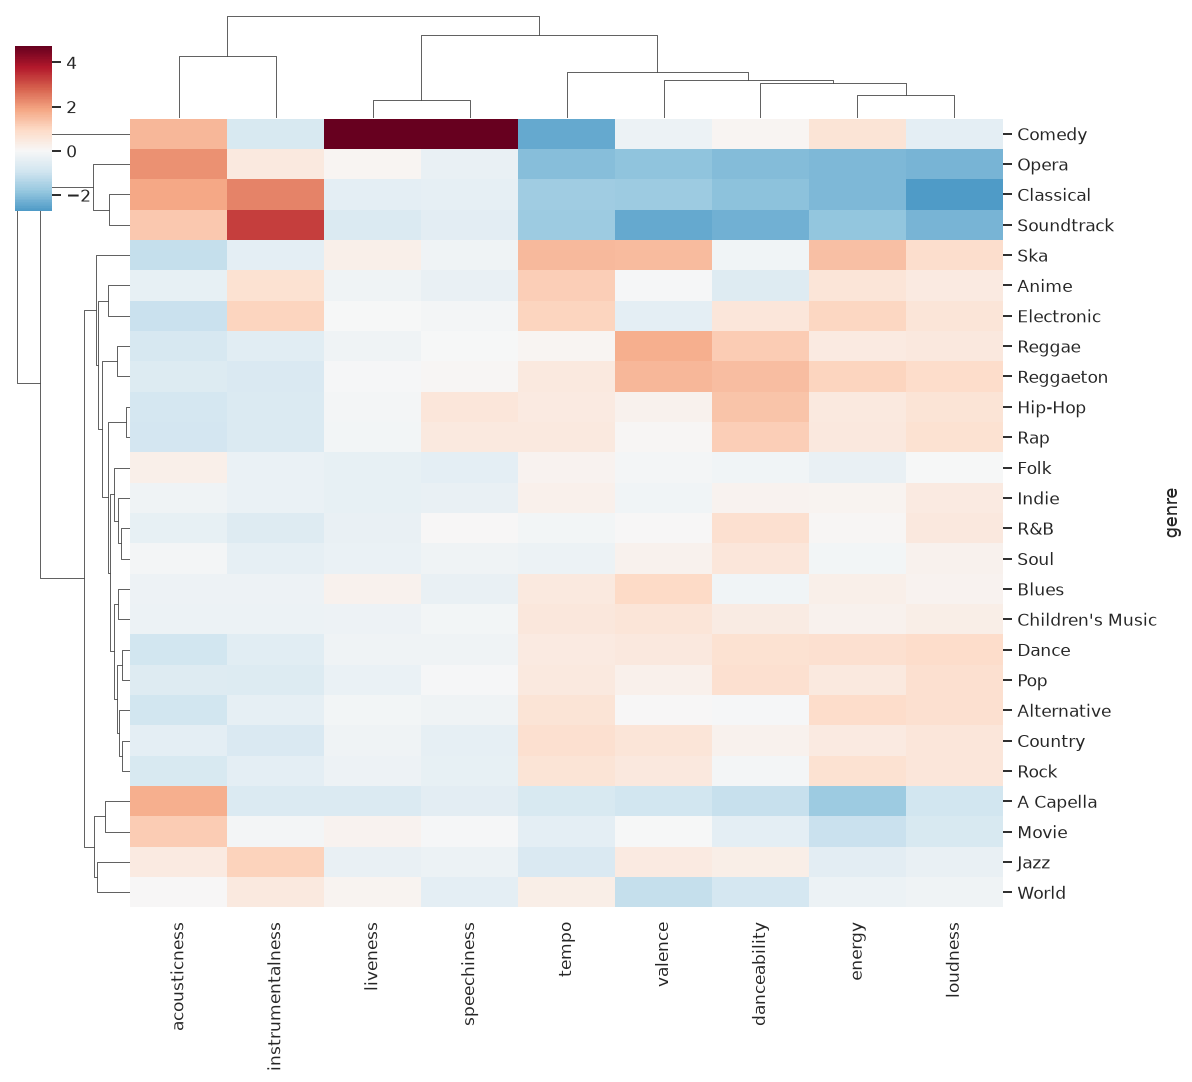

In [9]:
fp = a.groupby('genre')[AUDIO].mean()
fpz = (fp - fp.mean()) / fp.std()   # z-score each feature across genres
sns.clustermap(fpz, cmap='RdBu_r', center=0, figsize=(11, 10),
               dendrogram_ratio=.12, cbar_pos=(.02, .8, .03, .15))
plt.show()

**Takeaway:** the data is clean, spans a century, and every feature is defined and visualized. On to the four questions.